# Install Required Libraries

In [1]:
!pip install -q transformers datasets evaluate accelerate sentencepiece
!pip install -q torch torchvision torchaudio
!pip install -q nltk rouge_score pycocoevalcap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 8.3 MB/s eta 0:00:00


# Import Libraries and Check GPU

In [2]:
import os
import torch
import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

from torch.utils.data import Dataset

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator
)

print("Torch version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Torch version: 2.10.0+cu128
GPU Available: True
Using device: cuda


# Upload Dataset ZIP Directly to Colab

In [3]:
from google.colab import files

uploaded = files.upload()

Saving bhutan_dataset.zip to bhutan_dataset.zip


# Extract Dataset

In [4]:
import zipfile

ZIP_FILE = list(uploaded.keys())[0]

with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully.")

Dataset extracted successfully.


# Dataset Paths

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load FULL dataset
df = pd.read_csv("/content/bhutan_dataset/full_dataset.csv")

# First split: Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Second split: Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

# Check sizes
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

# Save split CSV files
train_df.to_csv("/content/bhutan_dataset/train.csv", index=False)
val_df.to_csv("/content/bhutan_dataset/val.csv", index=False)
test_df.to_csv("/content/bhutan_dataset/test.csv", index=False)

print("Dataset split completed.")

Train size: 113
Validation size: 24
Test size: 25
Dataset split completed.


In [10]:
DATA_DIR = "/content/bhutan_dataset"

IMAGE_DIR = os.path.join(DATA_DIR, "images")

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
VAL_CSV = os.path.join(DATA_DIR, "val.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")

OUTPUT_DIR = "/content/bhutan_blip_model"

MAX_TEXT_LEN = 48

# Verify Files

In [11]:
print("Train CSV exists:", os.path.exists(TRAIN_CSV))
print("Validation CSV exists:", os.path.exists(VAL_CSV))
print("Test CSV exists:", os.path.exists(TEST_CSV))
print("Image folder exists:", os.path.exists(IMAGE_DIR))

Train CSV exists: True
Validation CSV exists: True
Test CSV exists: True
Image folder exists: True


# Load CSV Files

In [12]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

train_df.head()

Train samples: 113
Validation samples: 24
Test samples: 25


,image,caption
0,68.jpg,A performer in traditional Bhutanese attire da...
1,116.JPG,A view of a traditional Bhutanese building loc...
2,12.jpg,"A panoramic view of Thimphu, the capital city ..."
3,66.jpg,A traditional Bhutanese exterior featuring sto...
4,86.jpg,A scenic view of a traditional Bhutanese monas...


# Preview Sample

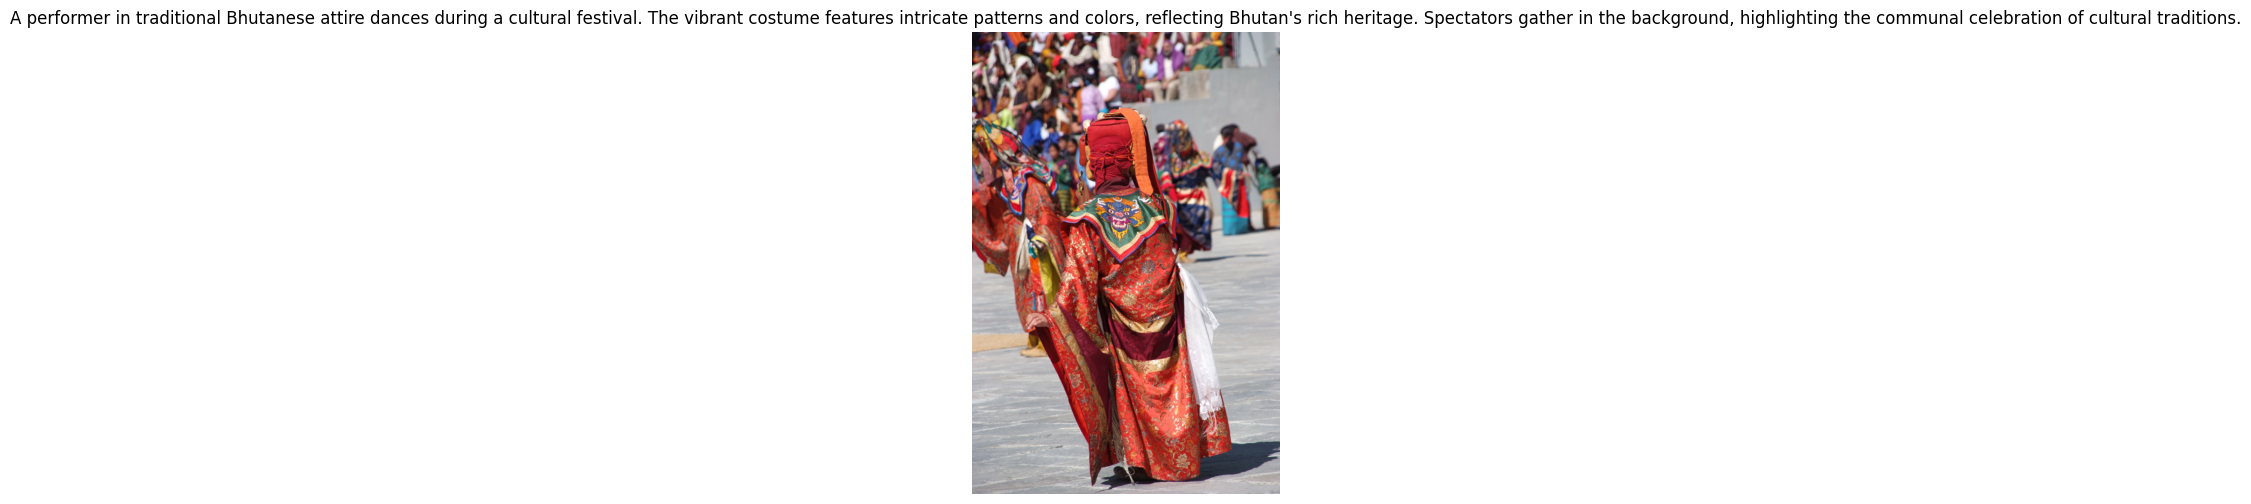

In [13]:
sample_image_name = train_df.iloc[0]["image"]
sample_caption = train_df.iloc[0]["caption"]

sample_image_path = os.path.join(IMAGE_DIR, sample_image_name)

img = Image.open(sample_image_path).convert("RGB")

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.title(sample_caption)
plt.show()

# Load BLIP Processor and Model

In [14]:
MODEL_NAME = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(MODEL_NAME)

model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME)

model.to(device)

print("BLIP model loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP model loaded successfully.


# Create Dataset Class

In [15]:
class BhutanCaptionDataset(Dataset):

    def __init__(self, dataframe, processor, image_dir, max_text_len=48):

        self.dataframe = dataframe
        self.processor = processor
        self.image_dir = image_dir
        self.max_text_len = max_text_len

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_name = row["image"]
        caption = str(row["caption"]).strip()

        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert("RGB")

        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_text_len,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)
        pixel_values = encoding["pixel_values"].squeeze(0)

        labels = input_ids.clone()

        labels[labels == processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

# Create Dataset Objects

In [16]:
train_dataset = BhutanCaptionDataset(
    train_df,
    processor,
    IMAGE_DIR,
    MAX_TEXT_LEN
)

val_dataset = BhutanCaptionDataset(
    val_df,
    processor,
    IMAGE_DIR,
    MAX_TEXT_LEN
)

test_dataset = BhutanCaptionDataset(
    test_df,
    processor,
    IMAGE_DIR,
    MAX_TEXT_LEN
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 113
Validation dataset: 24
Test dataset: 25


# Test Dataset Output

In [17]:
sample = train_dataset[0]

for k, v in sample.items():
    print(k, v.shape)

pixel_values torch.Size([3, 384, 384])
input_ids torch.Size([48])
attention_mask torch.Size([48])
labels torch.Size([48])


# Training Arguments

In [18]:
training_args = Seq2SeqTrainingArguments(

    output_dir=OUTPUT_DIR,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    learning_rate=5e-5,

    num_train_epochs=5,

    fp16=torch.cuda.is_available(),

    logging_steps=10,

    save_strategy="epoch",

    eval_strategy="epoch",

    predict_with_generate=True,

    remove_unused_columns=False,

    report_to="none"
)

# Create Trainer

In [19]:
trainer = Seq2SeqTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    data_collator=default_data_collator
)

# Train Model

In [20]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,2.720916,2.456558
2,1.695587,1.932921
3,1.045200,1.818850
4,0.575789,1.873633
5,0.298876,1.881671


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=285, training_loss=1.3982650857222707, metrics={'train_runtime': 255.4791, 'train_samples_per_second': 2.212, 'train_steps_per_second': 1.116, 'total_flos': 3.3533013813755904e+17, 'train_loss': 1.3982650857222707, 'epoch': 5.0})

# Save Fine-Tuned Model

In [21]:
trainer.save_model(OUTPUT_DIR)

processor.save_pretrained(OUTPUT_DIR)

print("Model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.


# Generate Caption Function

In [22]:
def generate_caption(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(device)

    output = model.generate(
        **inputs,
        max_length=50
    )

    caption = processor.decode(
        output[0],
        skip_special_tokens=True
    )

    return caption

# Test on One Image

Generated Caption:
a traditional bhutanese festival scene featuring performers in colorful costumes, showcasing cultural dance and music, set against a backdrop of mountains and blue skies. the backdrop showcases the rich cultural and communal spirit of bhutan.


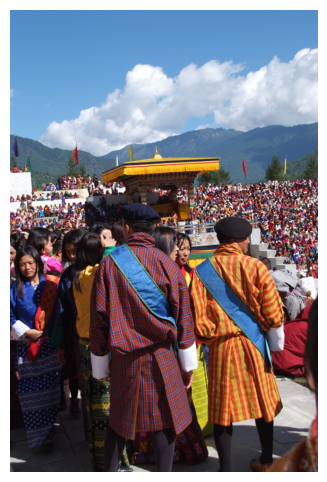

In [23]:
test_image = os.path.join(IMAGE_DIR, test_df.iloc[0]["image"])

generated_caption = generate_caption(test_image)

print("Generated Caption:")
print(generated_caption)

img = Image.open(test_image)

plt.figure(figsize=(8,6))
plt.imshow(img)
plt.axis("off")
plt.show()

# Generate Predictions on Test Set

In [24]:
predictions = []
references = []

for idx in range(len(test_df)):

    image_name = test_df.iloc[idx]["image"]

    real_caption = test_df.iloc[idx]["caption"]

    image_path = os.path.join(IMAGE_DIR, image_name)

    generated_caption = generate_caption(image_path)

    predictions.append(generated_caption)
    references.append(real_caption)

    print(f"\nImage: {image_name}")
    print("Generated:", generated_caption)
    print("Actual:", real_caption)


Image: 67.jpg
Generated: a traditional bhutanese festival scene featuring performers in colorful costumes, showcasing cultural dance and music, set against a backdrop of mountains and blue skies. the backdrop showcases the rich cultural and communal spirit of bhutan.
Actual: A gathering of people in traditional Bhutanese attire at a cultural festival, with vibrant clothing patterns and scenic mountains in the background. The event features elaborate architecture and colorful decorations, highlighting Bhutanese cultural elements amidst a large crowd.

Image: 37.jpg
Generated: two bhutanese monks in traditional attire stand on a bridge, overlooking a mountainous landscape. the architecture features intricate designs and colors, reflecting bhutan ' s rich cultural heritage. the landscape features lush greenery and rocky terrain typical of bhutan
Actual: The image showcases a traditional Bhutanese landscape with people walking across a bridge toward a prominent dzong, characterized by its

# Install Evaluation Metrics

In [25]:
!pip install -q evaluate

# BLEU Score

In [26]:
import evaluate

bleu = evaluate.load("bleu")

results = bleu.compute(
    predictions=predictions,
    references=[[r] for r in references]
)

print("BLEU Score:", results["bleu"])

BLEU Score: 0.10546091422670074


#ROUGE Score

In [27]:
rouge = evaluate.load("rouge")

results = rouge.compute(
    predictions=predictions,
    references=references
)

print(results)

{'rouge1': np.float64(0.4680464079523738), 'rouge2': np.float64(0.17899945691644253), 'rougeL': np.float64(0.33812008737240995), 'rougeLsum': np.float64(0.3392897714873679)}


# METEOR Score

In [28]:
meteor = evaluate.load("meteor")

results = meteor.compute(
    predictions=predictions,
    references=references
)

print("METEOR:", results["meteor"])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


METEOR: 0.38083245947241834


# Save Results CSV

In [29]:
results_df = pd.DataFrame({
    "Actual Caption": references,
    "Generated Caption": predictions
})

results_df.to_csv("/content/caption_results.csv", index=False)

results_df.head()

,Actual Caption,Generated Caption
0,A gathering of people in traditional Bhutanese...,a traditional bhutanese festival scene featuri...
1,The image showcases a traditional Bhutanese la...,two bhutanese monks in traditional attire stan...
2,The image features a traditional Bhutanese dzo...,"a traditional bhutanese fortress, known as a d..."
3,A traditional Bhutanese dancer wearing a color...,a performer wearing a traditional bhutanese ma...
4,A traditional Bhutanese dzong situated by a ri...,a traditional bhutanese monastery situated alo...


# Download Results

In [30]:
from google.colab import files

files.download("/content/caption_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>